In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [3]:
data = {
    "Income": [30000,40000,25000,80000,90000,35000,45000,70000,20000,60000],
    "LoanAmount": [10000,15000,12000,20000,25000,18000,14000,22000,10000,17000],
    "CreditScore": [650,700,580,750,800,620,680,730,550,710],
    "Default": [1,0,1,0,0,1,0,0,1,0]
}

df = pd.DataFrame(data)

df.head()

,Income,LoanAmount,CreditScore,Default
0,30000,10000,650,1
1,40000,15000,700,0
2,25000,12000,580,1
3,80000,20000,750,0
4,90000,25000,800,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Income       10 non-null     int64
 1   LoanAmount   10 non-null     int64
 2   CreditScore  10 non-null     int64
 3   Default      10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [5]:
df.describe()

,Income,LoanAmount,CreditScore,Default
count,10.000000,10.000000,10.000000,10.000000
mean,49500.000000,16300.000000,677.000000,0.400000
std,24203.994161,5056.349144,77.753171,0.516398
min,20000.000000,10000.000000,550.000000,0.000000
25%,31250.000000,12500.000000,627.500000,0.000000
50%,42500.000000,16000.000000,690.000000,0.000000
75%,67500.000000,19500.000000,725.000000,1.000000
max,90000.000000,25000.000000,800.000000,1.000000


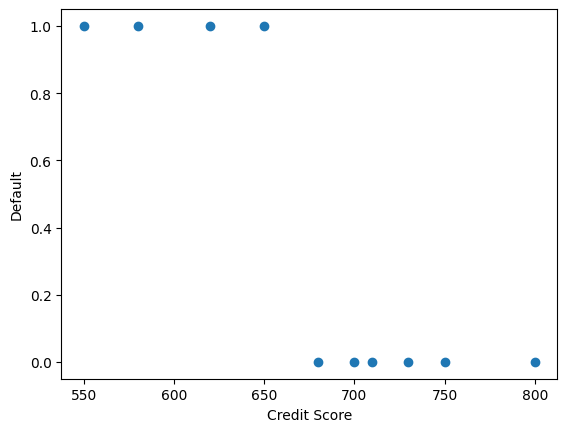

In [6]:
plt.scatter(df["CreditScore"], df["Default"])

plt.xlabel("Credit Score")
plt.ylabel("Default")

plt.show()

In [7]:
X = df[
    [
        "Income",
        "LoanAmount",
        "CreditScore"
    ]
]

y = df["Default"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
predictions = model.predict(X_test)

print(predictions)

[1 0]


In [11]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [12]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[1 0]
 [0 1]]


In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Income,0.414014
2,CreditScore,0.313314
1,LoanAmount,0.272672


In [15]:
new_applicant = [[50000, 15000, 680]]

prediction = model.predict(new_applicant)

if prediction[0] == 0:
    print("Low Risk")
else:
    print("High Risk")

Low Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
import joblib

joblib.dump(
    model,
    "credit_risk_model.pkl"
)

['credit_risk_model.pkl']